
Predicted percentages (first 20 patients):
 Patient  Diagnosis(1-Anxiety, 0-No Anxiety)  Logistic Regression (%)  Random Forest (%)  XGBoost (%)
 1       1                                   79.63                     78.46             73.27       
 2       0                                    0.30                      1.47              0.62       
 3       0                                    0.30                      4.00              0.57       
 4       0                                    5.54                     13.27              9.71       
 5       0                                    0.00                      0.18              0.00       
 6       0                                   57.42                     63.70             63.97       
 7       0                                   22.05                     29.86             28.32       
 8       0                                   17.39                     17.76             15.44       
 9       0                            

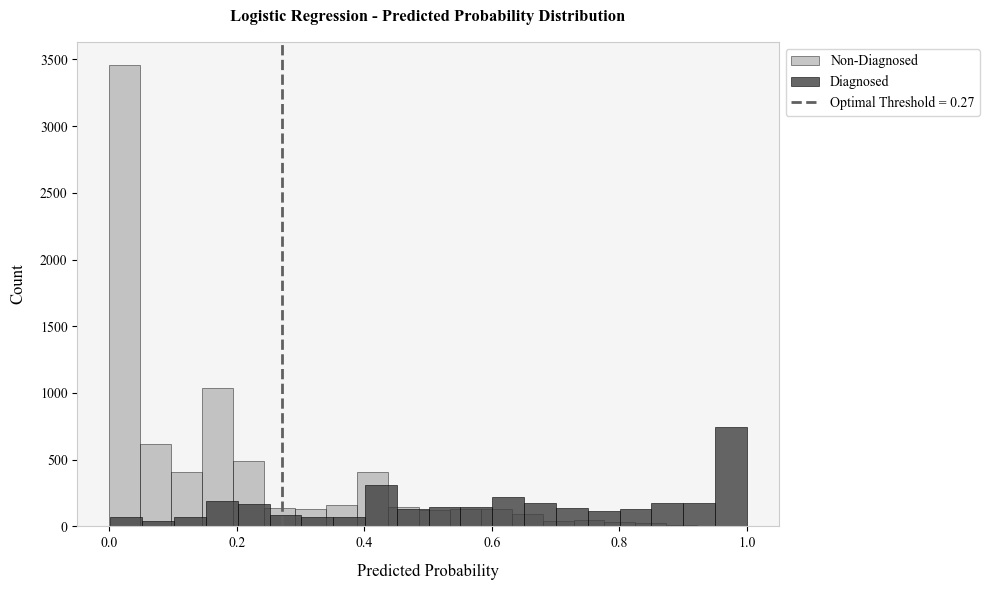

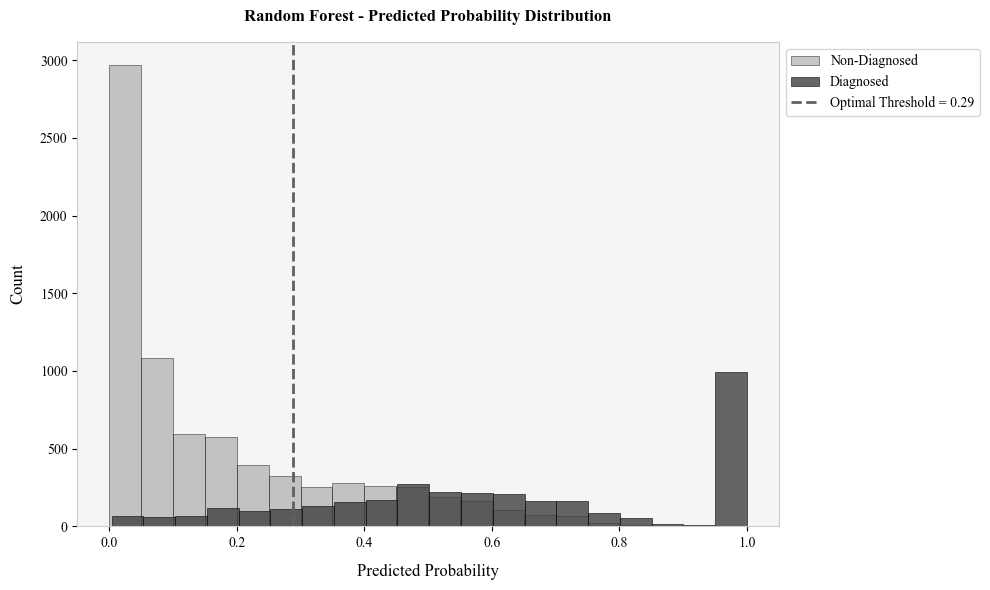

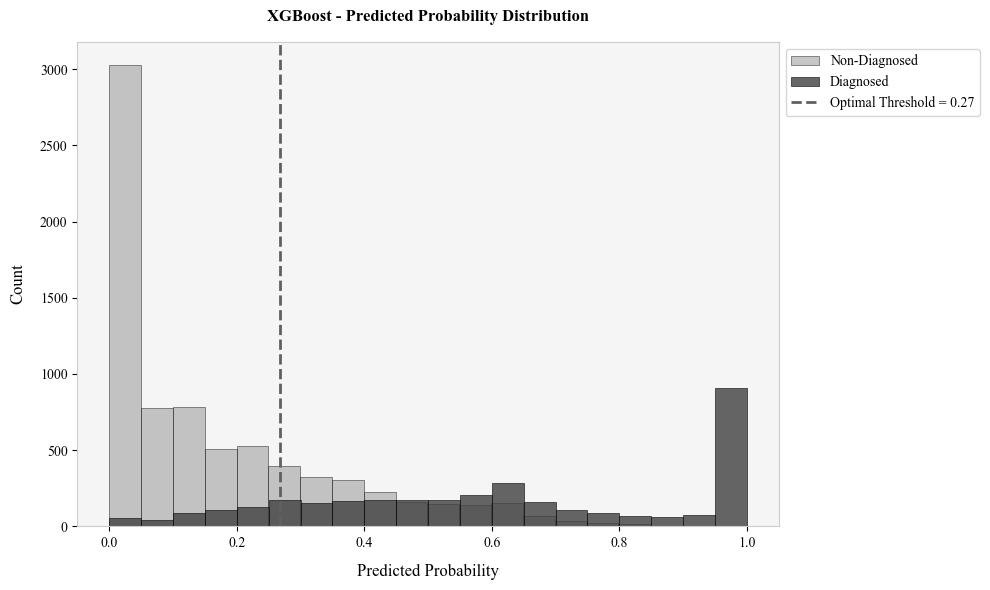


Top 15 features for Logistic Regression:
  Stress Level (1-10): 5.6844 (increases risk)
  Sleep Hours: -5.5939 (decreases risk)
  Therapy Sessions (per month): 1.6590 (increases risk)
  Caffeine Intake (mg/day): 1.6156 (increases risk)
  Age: -0.2478 (decreases risk)
  Alcohol Consumption (drinks/week): 0.2407 (increases risk)
  Heart Rate (bpm): 0.1888 (increases risk)
  Occupation_Student: -0.1786 (decreases risk)
  Medication: 0.1778 (increases risk)
  Recent Major Life Event: 0.1618 (increases risk)
  Occupation_Nurse: 0.1437 (increases risk)
  Occupation_Doctor: 0.1421 (increases risk)
  Sweating Level (1-5): 0.1274 (increases risk)
  Occupation_Other: 0.1060 (increases risk)
  Diet Quality (1-10): -0.0929 (decreases risk)


/tmp/ipykernel_2158/3673609007.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=10, frameon=True, loc='upper left', bbox_to_anchor=(1, 1))


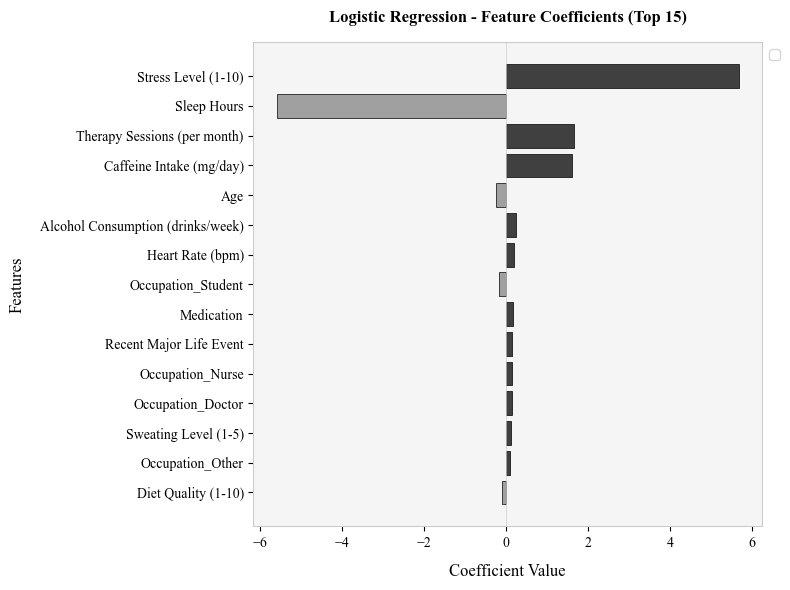


Top 15 features for Random Forest:
  Stress Level (1-10): 0.3114
  Sleep Hours: 0.1086
  Caffeine Intake (mg/day): 0.0850
  Physical Activity (hrs/week): 0.0589
  Therapy Sessions (per month): 0.0552
  Heart Rate (bpm): 0.0536
  Age: 0.0509
  Breathing Rate (breaths/min): 0.0438
  Alcohol Consumption (drinks/week): 0.0428
  Diet Quality (1-10): 0.0404
  Sweating Level (1-5): 0.0271
  Recent Major Life Event: 0.0100
  Medication: 0.0096
  Dizziness: 0.0095
  Gender_Other: 0.0089


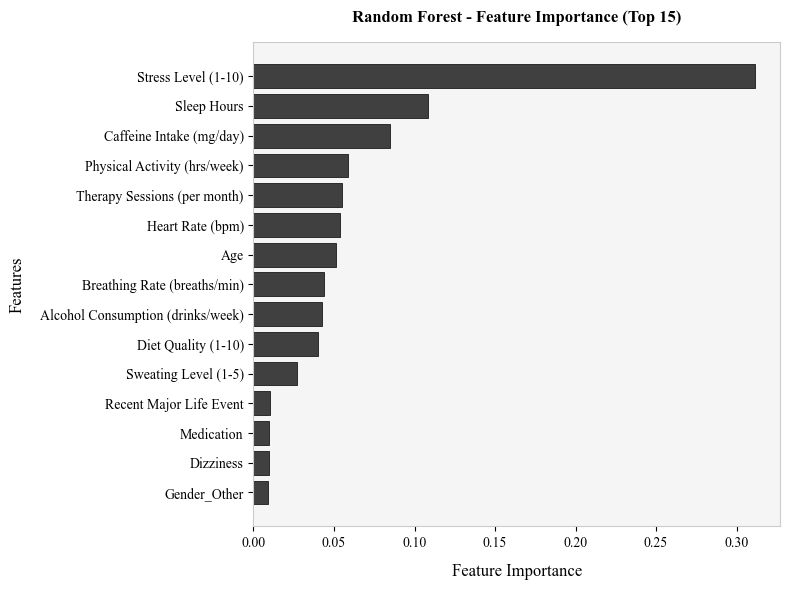


Top 15 features for XGBoost:
  Stress Level (1-10): 0.4402
  Sleep Hours: 0.0664
  Therapy Sessions (per month): 0.0482
  Caffeine Intake (mg/day): 0.0319
  Gender_Male: 0.0246
  Occupation_Athlete: 0.0218
  Occupation_Chef: 0.0201
  Occupation_Scientist: 0.0191
  Sweating Level (1-5): 0.0180
  Alcohol Consumption (drinks/week): 0.0176
  Occupation_Musician: 0.0176
  Diet Quality (1-10): 0.0166
  Occupation_Lawyer: 0.0164
  Age: 0.0162
  Physical Activity (hrs/week): 0.0162


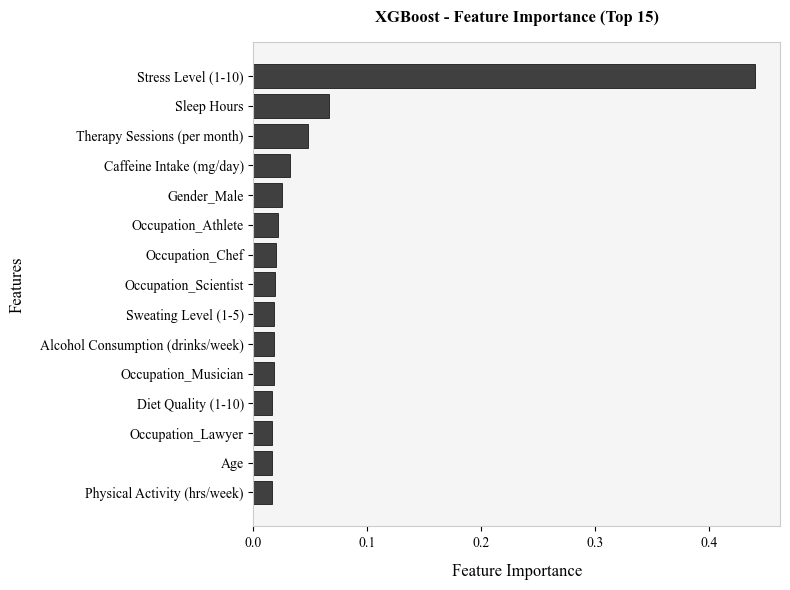

Logistic Regression METRICS (threshold=0.272)
Confusion Matrix:
  True Negatives: 6067
  False Positives: 1551
  False Negatives: 559
  True Positives: 2823

Key Performance Metrics:
  • SENSITIVITY (Recall/True Positive Rate): 0.8347 (83.47%)
  • SPECIFICITY (True Negative Rate): 0.7964 (79.64%)
  • F1-SCORE: 0.7280

Additional Metrics:
  Accuracy: 0.8082 (80.82%)
  Precision: 0.6454 (64.54%)
  ROC AUC: 0.9046
  Brier Score: 0.1114

Classification Report:
              precision    recall  f1-score   support

           0     0.9156    0.7964    0.8519      7618
           1     0.6454    0.8347    0.7280      3382

    accuracy                         0.8082     11000
   macro avg     0.7805    0.8156    0.7899     11000
weighted avg     0.8326    0.8082    0.8138     11000

Random Forest METRICS (threshold=0.288)
Confusion Matrix:
  True Negatives: 5891
  False Positives: 1727
  False Negatives: 484
  True Positives: 2898

Key Performance Metrics:
  • SENSITIVITY (Recall/True Positi

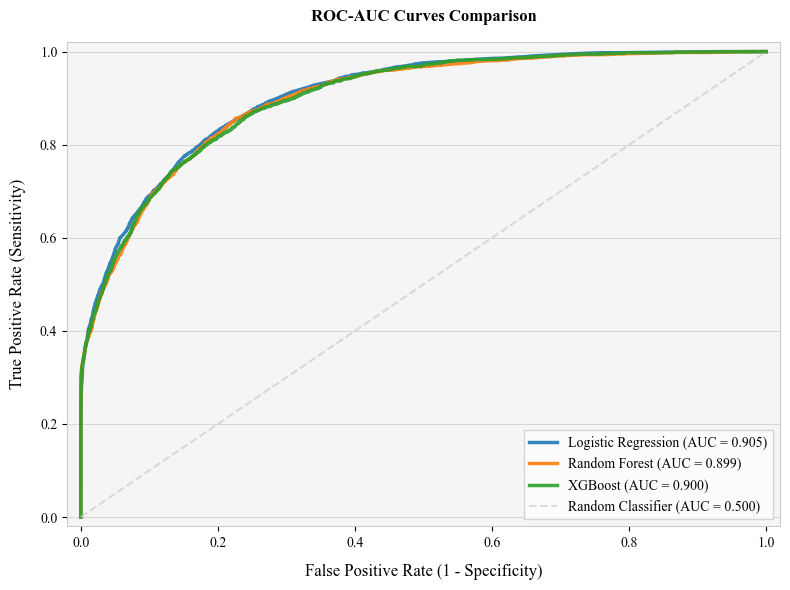

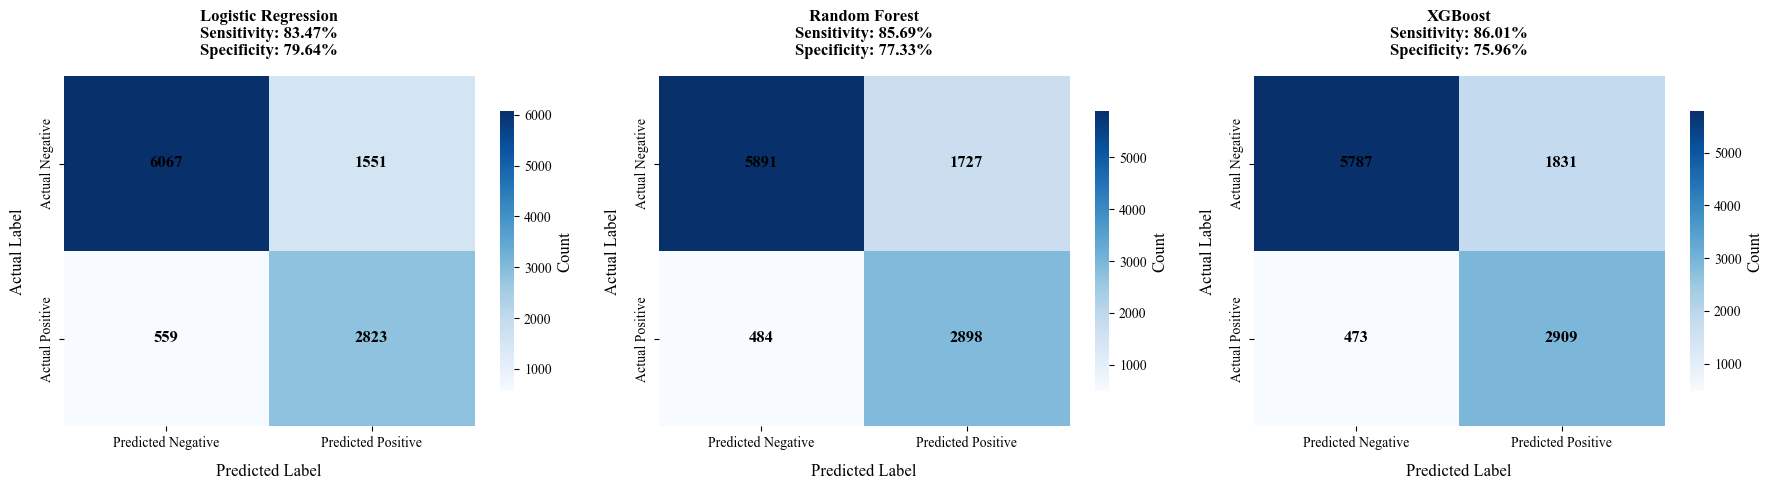

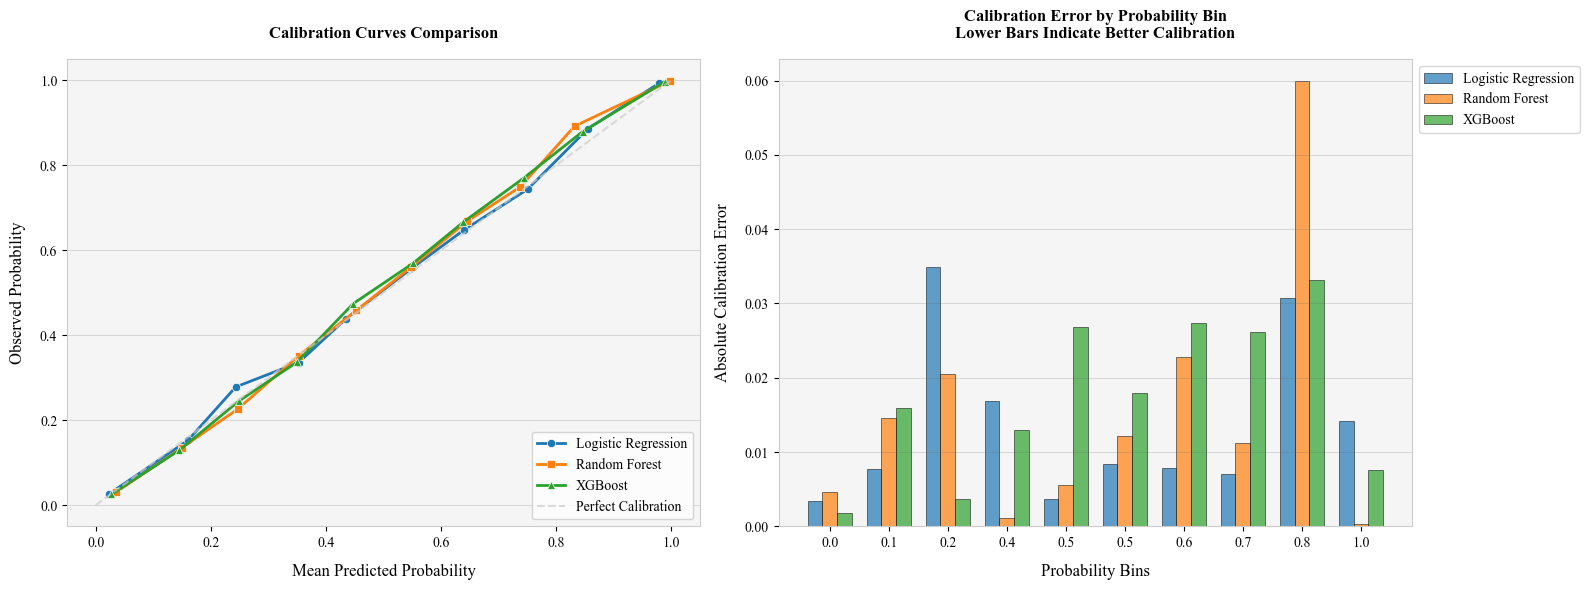


Generating SHAP Waterfall Plots for First 3 Patients...
NOTE: Using calibrated XGBoost model probabilities for display, SHAP values from uncalibrated model


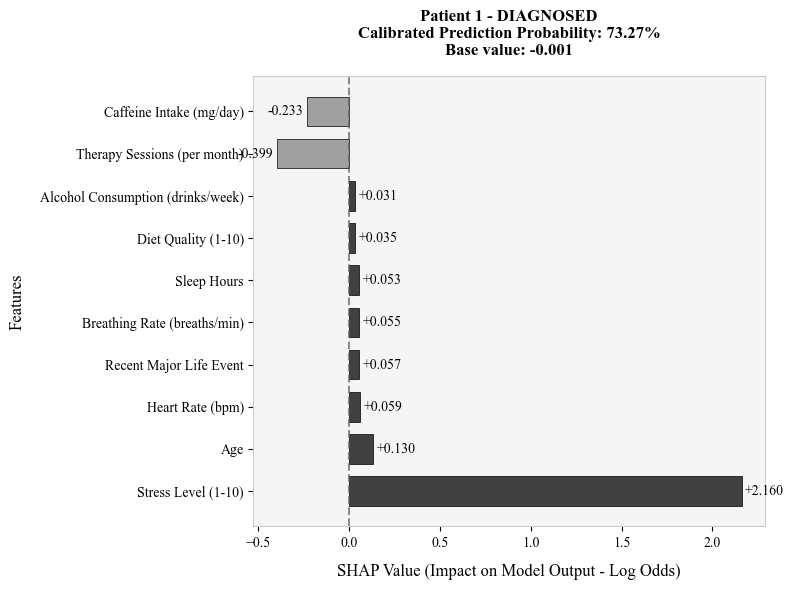

--------------------------------------------------------------------------------


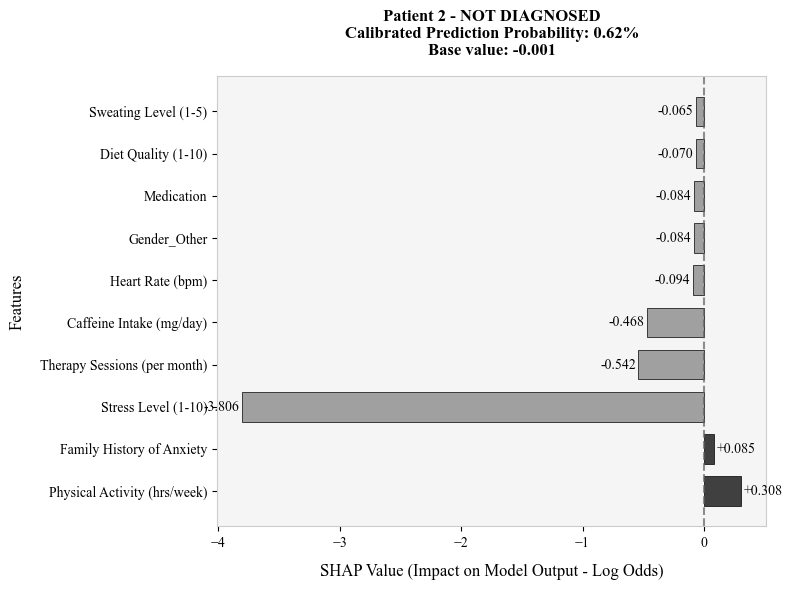

--------------------------------------------------------------------------------


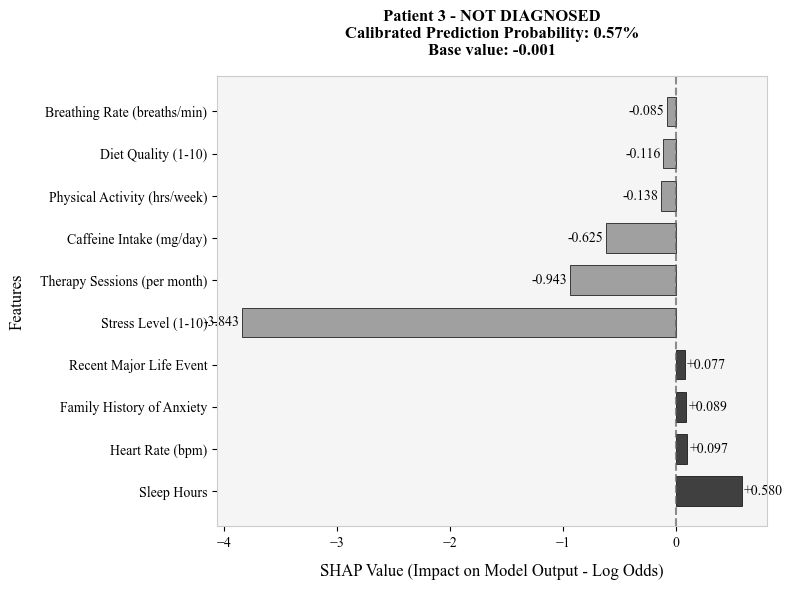

--------------------------------------------------------------------------------
RESULTS TABLE
FIRST 10 PATIENTS
Patient: 1     | Diagnosis: Diagnosed     | Prob: 73.27 % | Risk: High Risk   
  ↑ Increasing: Stress Level (1-10) (+2.160), Age (+0.130), Heart Rate (bpm) (+0.059), Recent Major Life Event (+0.057), Breathing Rate (breaths/min) (+0.055)
  ↓ Decreasing: Therapy Sessions (per month) (-0.399), Caffeine Intake (mg/day) (-0.233), Gender_Other (-0.022), Dizziness (-0.014), Smoking (-0.007)
--------------------------------------------------------------------------------------------------------------
Patient: 2     | Diagnosis: Not Diagnosed | Prob: 0.62  % | Risk: Low Risk    
  ↑ Increasing: Physical Activity (hrs/week) (+0.308), Family History of Anxiety (+0.085), Sleep Hours (+0.047), Occupation_Nurse (+0.039), Occupation_Student (+0.018)
  ↓ Decreasing: Stress Level (1-10) (-3.806), Therapy Sessions (per month) (-0.542), Caffeine Intake (mg/day) (-0.468), Heart Rate (bpm) (-0.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
from sklearn.utils import shuffle
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    roc_auc_score, accuracy_score, roc_curve, brier_score_loss,
    precision_score, recall_score, f1_score, confusion_matrix, classification_report
)

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.titlesize'] = 12
plt.rcParams['figure.dpi'] = 100

def style_plot(ax, title, xlabel, ylabel, legend=True, grid=True):
    ax.set_title(title, fontsize=12, fontweight='bold', pad=15, color='black')
    ax.set_xlabel(xlabel, fontsize=12, labelpad=10, color='black')
    ax.set_ylabel(ylabel, fontsize=12, labelpad=10, color='black')
    if grid:
        ax.grid(True, axis='y', alpha=0.3, linestyle='-', linewidth=0.5, color='#666666')
        ax.grid(False, axis='x')
    if legend:
        ax.legend(fontsize=10, frameon=True, loc='upper left', bbox_to_anchor=(1, 1))
    ax.tick_params(axis='both', which='major', labelsize=10, colors='black')
    ax.set_facecolor('#f5f5f5')
    ax.spines['top'].set_color('#cccccc')
    ax.spines['bottom'].set_color('#cccccc')
    ax.spines['left'].set_color('#cccccc')
    ax.spines['right'].set_color('#cccccc')
    return ax

train_data = pd.read_csv("training_dataset.csv")
X_train = train_data.drop(columns=["Diagnosed", "Anxiety Level (1-10)"])
y_train = train_data["Diagnosed"]
X_train, y_train = shuffle(X_train, y_train, random_state=42)

test_data = pd.read_csv("testing_dataset.csv")
X_test = test_data.drop(columns=["Diagnosed", "Anxiety Level (1-10)"])
y_test = test_data["Diagnosed"]

numeric_features = X_train.select_dtypes(include=[float, int]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

preprocessor = ColumnTransformer([
    ("num", MinMaxScaler(), numeric_features),
    ("cat", OneHotEncoder(drop="first", sparse_output=False), categorical_features)
])

logreg_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced",
                                      solver="saga", l1_ratio=0.5, C=1.0))
])

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=200,
                                          class_weight="balanced", random_state=42))
])

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                                 eval_metric="logloss", scale_pos_weight=scale_pos_weight, random_state=42))
])

logreg_model = CalibratedClassifierCV(logreg_pipeline, method="isotonic", cv=5)
rf_model = CalibratedClassifierCV(rf_pipeline, method="isotonic", cv=5)
xgb_model = CalibratedClassifierCV(xgb_pipeline, method="isotonic", cv=5)

logreg_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

logreg_prob = logreg_model.predict_proba(X_test)[:, 1]
rf_prob = rf_model.predict_proba(X_test)[:, 1]
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

print("\nPredicted percentages (first 20 patients):")
df_probs = pd.DataFrame({
    "Patient": range(1, 21),
    "Diagnosis(1-Anxiety, 0-No Anxiety)": y_test.iloc[:20].values,
    "Logistic Regression (%)": np.round(logreg_prob[:20]*100, 2),
    "Random Forest (%)": np.round(rf_prob[:20]*100, 2),
    "XGBoost (%)": np.round(xgb_prob[:20]*100, 2)
})
print(df_probs.to_string(index=False))

def find_best_threshold(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    best_idx = np.argmax(tpr - fpr)
    return thresholds[best_idx]

logreg_threshold = find_best_threshold(y_test, logreg_prob)
rf_threshold = find_best_threshold(y_test, rf_prob)
xgb_threshold = find_best_threshold(y_test, xgb_prob)

def plot_probabilities_horizontal(y_true, y_prob, threshold, name):
    df = pd.DataFrame({"Probability": y_prob, "Diagnosis": y_true})
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = ['#a0a0a0', '#404040']
    for i, diagnosis in enumerate([0, 1]):
        data = df[df["Diagnosis"] == diagnosis]
        label = "Non-Diagnosed" if diagnosis == 0 else "Diagnosed"
        alpha = 0.6 if diagnosis == 0 else 0.8
        ax.hist(data["Probability"], bins=20, alpha=alpha, color=colors[i],
                label=label, edgecolor='black', linewidth=0.5)
    ax.axvline(threshold, color='#606060', linestyle="--", linewidth=2,
               label=f"Optimal Threshold = {threshold:.2f}")
    ax = style_plot(ax, f"{name} - Predicted Probability Distribution",
                    "Predicted Probability", "Count", grid=False)
    plt.tight_layout()
    plt.show()

plot_probabilities_horizontal(y_test, logreg_prob, logreg_threshold, "Logistic Regression")
plot_probabilities_horizontal(y_test, rf_prob, rf_threshold, "Random Forest")
plot_probabilities_horizontal(y_test, xgb_prob, xgb_threshold, "XGBoost")

def plot_feature_importance(pipeline_model, name):
    classifier = pipeline_model.named_steps["classifier"]
    preprocessor_temp = ColumnTransformer([
        ("num", MinMaxScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", sparse_output=False), categorical_features)
    ])
    preprocessor_temp.fit(X_train)
    numeric_feature_names = numeric_features
    cat_feature_names = preprocessor_temp.named_transformers_["cat"].get_feature_names_out(categorical_features)
    feature_names = list(numeric_feature_names) + list(cat_feature_names)
    fig, ax = plt.subplots(figsize=(8, 6))
    if hasattr(classifier, "feature_importances_"):
        importances = classifier.feature_importances_
        indices = np.argsort(importances)[-15:]
        bars = ax.barh(range(len(indices)), importances[indices], color='#404040',
                       edgecolor='black', linewidth=0.5)
        ax.set_yticks(range(len(indices)))
        ax.set_yticklabels([feature_names[i] for i in indices], fontsize=10)
        ax = style_plot(ax, f"{name} - Feature Importance (Top 15)",
                        "Feature Importance", "Features", legend=False, grid=False)
        print(f"\nTop 15 features for {name}:")
        for idx in reversed(indices):
            print(f"  {feature_names[idx]}: {importances[idx]:.4f}")
    elif hasattr(classifier, "coef_"):
        coefficients = classifier.coef_[0]
        abs_coef = np.abs(coefficients)
        indices = np.argsort(abs_coef)[-15:]
        colors = ['#404040' if c > 0 else '#a0a0a0' for c in coefficients[indices]]
        ax.barh(range(len(indices)), coefficients[indices], color=colors,
                edgecolor='black', linewidth=0.5)
        ax.set_yticks(range(len(indices)))
        ax.set_yticklabels([feature_names[i] for i in indices], fontsize=10)
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor='#404040', edgecolor='black', label='Positive (increases risk)'),
                           Patch(facecolor='#a0a0a0', edgecolor='black', label='Negative (decreases risk)')]
        ax.legend(handles=legend_elements, loc='lower right', fontsize=10,
                  frameon=True)
        ax = style_plot(ax, f"{name} - Feature Coefficients (Top 15)",
                        "Coefficient Value", "Features", legend=True, grid=False)
        print(f"\nTop 15 features for {name}:")
        for idx in reversed(indices):
            direction = "increases risk" if coefficients[idx] > 0 else "decreases risk"
            print(f"  {feature_names[idx]}: {coefficients[idx]:.4f} ({direction})")
    ax.axvline(x=0, color='#cccccc', linestyle='-', linewidth=0.5)
    plt.tight_layout()
    plt.show()

logreg_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)
xgb_pipeline.fit(X_train, y_train)

plot_feature_importance(logreg_pipeline, "Logistic Regression")
plot_feature_importance(rf_pipeline, "Random Forest")
plot_feature_importance(xgb_pipeline, "XGBoost")

def evaluate_model(y_true, y_prob, threshold, name):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)
    brier = brier_score_loss(y_true, y_prob)
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    print(f"{name} METRICS (threshold={threshold:.3f})")
    print(f"Confusion Matrix:")
    print(f"  True Negatives: {tn}")
    print(f"  False Positives: {fp}")
    print(f"  False Negatives: {fn}")
    print(f"  True Positives: {tp}")
    print(f"\nKey Performance Metrics:")
    print(f"  • SENSITIVITY (Recall/True Positive Rate): {sensitivity:.4f} ({sensitivity*100:.2f}%)")
    print(f"  • SPECIFICITY (True Negative Rate): {specificity:.4f} ({specificity*100:.2f}%)")
    print(f"  • F1-SCORE: {f1:.4f}")
    print(f"\nAdditional Metrics:")
    print(f"  Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    print(f"  Precision: {prec:.4f} ({prec*100:.2f}%)")
    print(f"  ROC AUC: {roc_auc:.4f}")
    print(f"  Brier Score: {brier:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_true, y_pred, digits=4))
    return confusion_matrix(y_true, y_pred), {
        'sensitivity': sensitivity,
        'specificity': specificity,
        'f1_score': f1,
        'precision': prec,
        'accuracy': acc,
        'roc_auc': roc_auc
    }

logreg_cm, logreg_metrics = evaluate_model(y_test, logreg_prob, logreg_threshold, "Logistic Regression")
rf_cm, rf_metrics = evaluate_model(y_test, rf_prob, rf_threshold, "Random Forest")
xgb_cm, xgb_metrics = evaluate_model(y_test, xgb_prob, xgb_threshold, "XGBoost")

comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Threshold': [logreg_threshold, rf_threshold, xgb_threshold],
    'Sensitivity (%)': [logreg_metrics['sensitivity']*100, rf_metrics['sensitivity']*100, xgb_metrics['sensitivity']*100],
    'Specificity (%)': [logreg_metrics['specificity']*100, rf_metrics['specificity']*100, xgb_metrics['specificity']*100],
    'F1-Score': [logreg_metrics['f1_score'], rf_metrics['f1_score'], xgb_metrics['f1_score']],
    'Precision (%)': [logreg_metrics['precision']*100, rf_metrics['precision']*100, xgb_metrics['precision']*100],
    'Accuracy (%)': [logreg_metrics['accuracy']*100, rf_metrics['accuracy']*100, xgb_metrics['accuracy']*100],
    'ROC-AUC': [logreg_metrics['roc_auc'], rf_metrics['roc_auc'], xgb_metrics['roc_auc']]
}).round(2)

print("\nMODEL COMPARISON SUMMARY\n", comparison_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
models = [
    ("Logistic Regression", logreg_prob, colors[0]),
    ("Random Forest", rf_prob, colors[1]),
    ("XGBoost", xgb_prob, colors[2])
]
for model_name, prob, color in models:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, color=color, linewidth=2.5, linestyle='-',
            label=f"{model_name} (AUC = {auc:.3f})", alpha=0.9)
ax.plot([0, 1], [0, 1], color='#cccccc', linestyle='--', linewidth=1.5, alpha=0.7,
        label='Random Classifier (AUC = 0.500)')
ax = style_plot(ax, "ROC-AUC Curves Comparison",
                "False Positive Rate (1 - Specificity)",
                "True Positive Rate (Sensitivity)",
                legend=True, grid=True)
ax.legend(fontsize=10, frameon=True, loc='lower right',
          fancybox=False, edgecolor='#cccccc')
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
ax.grid(True, which='minor', alpha=0.15, linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sensitivity_labels = [
    f"Sensitivity: {logreg_metrics['sensitivity']:.2%}\nSpecificity: {logreg_metrics['specificity']:.2%}",
    f"Sensitivity: {rf_metrics['sensitivity']:.2%}\nSpecificity: {rf_metrics['specificity']:.2%}",
    f"Sensitivity: {xgb_metrics['sensitivity']:.2%}\nSpecificity: {xgb_metrics['specificity']:.2%}"
]
model_names = ['Logistic Regression', 'Random Forest', 'XGBoost']
for idx, (cm, ax, label, name) in enumerate(zip([logreg_cm, rf_cm, xgb_cm], axes, sensitivity_labels, model_names)):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=['Predicted Negative', 'Predicted Positive'],
                yticklabels=['Actual Negative', 'Actual Positive'],
                annot_kws={'size': 12, 'color': 'black', 'fontweight': 'bold'},
                cbar_kws={'label': 'Count', 'shrink': 0.8})
    ax.set_xlabel("Predicted Label", fontsize=12, labelpad=10, color='black')
    ax.set_ylabel("Actual Label", fontsize=12, labelpad=10, color='black')
    ax.set_title(f"{name}\n{label}", fontsize=12, fontweight='bold', pad=15, color='black')
    ax.tick_params(axis='both', which='major', labelsize=10, colors='black')
    ax.set_facecolor('#f5f5f5')
    for spine in ax.spines.values():
        spine.set_color('#cccccc')
plt.tight_layout()
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
markers = ['o', 's', '^']
calibration_data = []
for prob, label, color, marker in zip([logreg_prob, rf_prob, xgb_prob],
                                       ["Logistic Regression", "Random Forest", "XGBoost"],
                                       colors, markers):
    prob_true, prob_pred = calibration_curve(y_test, prob, n_bins=10)
    calibration_data.append((prob_pred, prob_true, label, color, marker))
    ax1.plot(prob_pred, prob_true, marker=marker, markersize=6, linewidth=2,
             linestyle='-', color=color, label=label,
             markeredgecolor='white', markeredgewidth=0.5)

ax1.plot([0,1], [0,1], linestyle='--', color='#cccccc', linewidth=1.5, alpha=0.7,
         label='Perfect Calibration')
ax1.set_title('Calibration Curves Comparison', fontsize=12, fontweight='bold', pad=15, color='black')
ax1.set_xlabel('Mean Predicted Probability', fontsize=12, labelpad=10, color='black')
ax1.set_ylabel('Observed Probability', fontsize=12, labelpad=10, color='black')
ax1.grid(True, axis='y', alpha=0.3, linestyle='-', linewidth=0.5, color='#666666')
ax1.grid(False, axis='x')
ax1.legend(fontsize=10, frameon=True, loc='lower right')
ax1.tick_params(axis='both', which='major', labelsize=10, colors='black')
ax1.set_facecolor('#f5f5f5')
for spine in ax1.spines.values():
    spine.set_color('#cccccc')

bar_width = 0.25
index = np.arange(10)
for i, (prob_pred, prob_true, label, color, marker) in enumerate(calibration_data):
    deviations = np.abs(prob_true - prob_pred)
    offset = (i - 1) * bar_width
    ax2.bar(index + offset, deviations, bar_width, label=f'{label}',
            color=color, alpha=0.7, edgecolor='black', linewidth=0.5)

ax2.set_xlabel('Probability Bins', fontsize=12, labelpad=10, color='black')
ax2.set_ylabel('Absolute Calibration Error', fontsize=12, labelpad=10, color='black')
ax2.set_title('Calibration Error by Probability Bin\nLower Bars Indicate Better Calibration', 
              fontsize=12, fontweight='bold', pad=15, color='black')
ax2.set_xticks(index)
ax2.set_xticklabels([f'{x:.1f}' for x in calibration_data[1][0]], fontsize=10)
ax2.legend(fontsize=10, frameon=True, loc='upper left', bbox_to_anchor=(1, 1))
ax2.grid(True, axis='y', alpha=0.3, linestyle='-', linewidth=0.5, color='#666666')
ax2.set_facecolor('#f5f5f5')
for spine in ax2.spines.values():
    spine.set_color('#cccccc')

plt.tight_layout()
plt.show()

preprocessor_temp = ColumnTransformer([
    ("num", MinMaxScaler(), numeric_features),
    ("cat", OneHotEncoder(drop="first", sparse_output=False), categorical_features)
])
preprocessor_temp.fit(X_train)
numeric_feature_names = numeric_features
cat_feature_names = preprocessor_temp.named_transformers_["cat"].get_feature_names_out(categorical_features)
feature_names = list(numeric_feature_names) + list(cat_feature_names)
X_train_transformed = preprocessor_temp.transform(X_train)
X_test_transformed = preprocessor_temp.transform(X_test)
xgb_model_uncalibrated = xgb_pipeline.named_steps['classifier']
explainer = shap.TreeExplainer(xgb_model_uncalibrated)
shap_values = explainer.shap_values(X_test_transformed)
xgb_calibrated_prob = xgb_prob

def plot_grayscale_waterfall(shap_values, expected_value, features, feature_names, calibrated_prob, true_diagnosis, max_display=10, patient_num=None):
    feature_impacts = list(zip(feature_names, shap_values))
    feature_impacts.sort(key=lambda x: abs(x[1]), reverse=True)
    top_features = feature_impacts[:max_display]
    positive_features = [(name, val) for name, val in top_features if val > 0]
    negative_features = [(name, val) for name, val in top_features if val < 0]
    positive_features.sort(key=lambda x: x[1], reverse=True)
    negative_features.sort(key=lambda x: x[1])
    sorted_features = positive_features + negative_features
    fig, ax = plt.subplots(figsize=(8, 6))
    y_positions = range(len(sorted_features))
    bar_colors = []
    bar_values = []
    feature_labels = []
    for i, (name, impact) in enumerate(sorted_features):
        feature_labels.append(name)
        bar_values.append(impact)
        if impact > 0:
            bar_colors.append('#404040')
        else:
            bar_colors.append('#a0a0a0')
    bars = ax.barh(y_positions, bar_values, color=bar_colors,
                   edgecolor='black', linewidth=0.5, height=0.7)
    for i, (impact, bar) in enumerate(zip(bar_values, bars)):
        if impact > 0:
            ax.text(impact + 0.02, i, f'+{impact:.3f}',
                    va='center', fontsize=10, color='black')
        else:
            ax.text(impact - 0.02, i, f'{impact:.3f}',
                    va='center', ha='right', fontsize=10, color='black')
    ax.set_yticks(y_positions)
    ax.set_yticklabels(feature_labels, fontsize=13)
    ax.axvline(x=expected_value, color='#606060', linestyle='--',
               linewidth=1.5, alpha=0.7)
    final_prediction = expected_value + sum(bar_values)
    calculated_probability = 1 / (1 + np.exp(-final_prediction))
    diagnosis_text = 'DIAGNOSED' if true_diagnosis == 1 else 'NOT DIAGNOSED'
    title = f"Patient {patient_num} - {diagnosis_text}\nCalibrated Prediction Probability: {calibrated_prob:.2%}\nBase value: {expected_value:.3f}"
    ax.set_title(title, fontsize=12, fontweight='bold', pad=15, color='black')
    ax.set_xlabel('SHAP Value (Impact on Model Output - Log Odds)', fontsize=12, labelpad=10, color='black')
    ax.set_ylabel('Features', fontsize=12, labelpad=10, color='black')
    ax.grid(False)
    ax.tick_params(axis='both', which='major', labelsize=10, colors='black')
    ax.set_facecolor('#f5f5f5')
    for spine in ax.spines.values():
        spine.set_color('#cccccc')
    plt.tight_layout()
    plt.show()

print("\nGenerating SHAP Waterfall Plots for First 3 Patients...")
print("NOTE: Using calibrated XGBoost model probabilities for display, SHAP values from uncalibrated model")
for i in range(min(3, len(X_test))):
    true_diagnosis = y_test.iloc[i]
    calibrated_prob = xgb_calibrated_prob[i]
    plot_grayscale_waterfall(
        shap_values[i],
        explainer.expected_value,
        X_test_transformed[i],
        feature_names,
        calibrated_prob,
        true_diagnosis,
        max_display=10,
        patient_num=i+1
    )
    print("-" * 80)

print("RESULTS TABLE")

def get_top_shap_features(shap_values_row, feature_names, n_top=5, positive=True):
    if positive:
        indices = np.argsort(shap_values_row)[-n_top:][::-1]
    else:
        indices = np.argsort(shap_values_row)[:n_top]
    features = []
    for idx in indices:
        if positive and shap_values_row[idx] > 0:
            features.append(f"{feature_names[idx]} (+{shap_values_row[idx]:.3f})")
        elif not positive and shap_values_row[idx] < 0:
            features.append(f"{feature_names[idx]} ({shap_values_row[idx]:.3f})")
    while len(features) < n_top:
        features.append("")
    return features

def categorize_risk(prob, low_thresh=0.3, high_thresh=0.7):
    if prob < low_thresh:
        return "Low Risk"
    elif prob < high_thresh:
        return "Moderate Risk"
    else:
        return "High Risk"

xgb_risk_category = [categorize_risk(p) for p in xgb_prob]
top_increase_features = []
top_decrease_features = []
for i in range(len(xgb_prob)):
    increase_features = get_top_shap_features(shap_values[i], feature_names, n_top=5, positive=True)
    decrease_features = get_top_shap_features(shap_values[i], feature_names, n_top=5, positive=False)
    top_increase_features.append(increase_features)
    top_decrease_features.append(decrease_features)

results_table = pd.DataFrame({
    "Patient": range(1, len(xgb_prob) + 1),
    "Diagnosis(1-Anxiety, 0-No Anxiety)": ["Diagnosed" if val == 1 else "Not Diagnosed" for val in y_test.values],
    "Predicted Prob (%)": np.round(xgb_prob * 100, 2),
    "Risk Category": xgb_risk_category,
    "Top 5 Increasing Risk Factors": [", ".join([f for f in feat if f != ""]) for feat in top_increase_features],
    "Top 5 Decreasing Risk Factors": [", ".join([f for f in feat if f != ""]) for feat in top_decrease_features]
})

pd.set_option('display.max_colwidth', 50)
pd.set_option('display.width', 120)
pd.set_option('display.colheader_justify', 'left')

print("FIRST 10 PATIENTS")
for i in range(min(10, len(results_table))):
    row = results_table.iloc[i]
    print(f"Patient: {row['Patient']:<5} | Diagnosis: {row['Diagnosis(1-Anxiety, 0-No Anxiety)']:<13} | "
          f"Prob: {row['Predicted Prob (%)']:<6}% | Risk: {row['Risk Category']:<12}")
    print(f"  ↑ Increasing: {row['Top 5 Increasing Risk Factors']}")
    print(f"  ↓ Decreasing: {row['Top 5 Decreasing Risk Factors']}")
    print("-" * 110)

print("LAST 10 PATIENTS")
start_idx = max(0, len(results_table) - 10)
for i in range(start_idx, len(results_table)):
    row = results_table.iloc[i]
    print(f"Patient: {row['Patient']:<5} | Diagnosis: {row['Diagnosis(1-Anxiety, 0-No Anxiety)']:<13} | "
          f"Prob: {row['Predicted Prob (%)']:<6}% | Risk: {row['Risk Category']:<12}")
    print(f"  ↑ Increasing: {row['Top 5 Increasing Risk Factors']}")
    print(f"  ↓ Decreasing: {row['Top 5 Decreasing Risk Factors']}")
    print("-" * 110)

results_table.to_csv("predictions_with_explanation.csv", index=False)
print("\nFull results table saved to 'predictions_with_explanation.csv'")

print("RISK CATEGORY DISTRIBUTION")
risk_summary = results_table.groupby('Risk Category').agg({
    'Patient': 'count',
}).rename(columns={'Patient': 'Count'})
risk_summary['Percentage'] = (risk_summary['Count'] / len(results_table) * 100).round(2)
print(risk_summary.to_string())

joblib.dump(xgb_model, 'predictive_model.pkl', compress=3)
print("\nModel saved as predictive_model.pkl")